In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Project Overview

This project analyzes an online retail transaction dataset to understand
sales performance, customer purchasing behavior, product performance,
and geographical sales patterns.

The goal is to use Python, Pandas, NumPy, Matplotlib, and Seaborn
to perform exploratory data analysis and extract meaningful business insights.

## Business Questions

1. What are the top-selling products?
2. Which products generate the highest revenue?
3. Which countries generate the most revenue?
4. How does revenue change over time?
5. What is the distribution of order values?
6. Which customers generate the highest revenue?
7. Is there a relationship between quantity and unit price?
8. Which countries have different purchasing patterns?
9. What are the major correlations between numerical variables?
10. What business insights can be extracted from the data?

In [59]:
from ucimlrepo import fetch_ucirepo

online_retail = fetch_ucirepo(id=352)

df = online_retail.data.features

df.head()

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [60]:
df.shape


(541909, 6)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Description  540455 non-null  object 
 1   Quantity     541909 non-null  int64  
 2   InvoiceDate  541909 non-null  object 
 3   UnitPrice    541909 non-null  float64
 4   CustomerID   406829 non-null  float64
 5   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 24.8+ MB


In [62]:
df.describe()




,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [63]:
df.isnull().sum()

Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [64]:
df.nunique()

Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

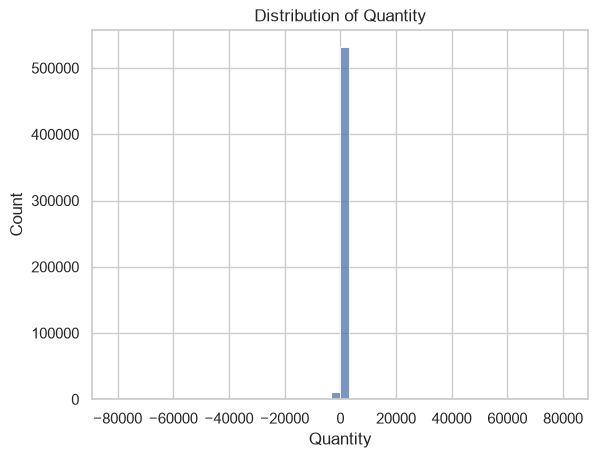

In [65]:
sns.set(style="whitegrid")
sns.histplot(data=df,x="Quantity",bins=50)
plt.title("Distribution of Quantity")
plt.show()

In [66]:
df["Quantity"].describe()

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

In [67]:
df["UnitPrice"].describe()

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [68]:
df["UnitPrice"].sort_values().head(20)

299983   -11062.06
299984   -11062.06
204602        0.00
387137        0.00
387138        0.00
387139        0.00
423946        0.00
204603        0.00
204604        0.00
387140        0.00
387141        0.00
387142        0.00
397212        0.00
204598        0.00
204599        0.00
204600        0.00
204601        0.00
51762         0.00
170532        0.00
51760         0.00
Name: UnitPrice, dtype: float64

In [69]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 6007


In [70]:
print("Shape before removing duplicates:", df.shape)

Shape before removing duplicates: (541909, 6)


In [71]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (535902, 6)


In [72]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Description      1370
CustomerID     134374
dtype: int64


In [73]:
print("Negative Quantity:", (df["Quantity"] < 0).sum())
print("Zero Quantity:", (df["Quantity"] == 0).sum())


Negative Quantity: 10544
Zero Quantity: 0


In [74]:
print("Negative UnitPrice:", (df["UnitPrice"] < 0).sum())
print("Zero UnitPrice:", (df["UnitPrice"] == 0).sum())
print(df[df["UnitPrice"] <= 0].head())

Negative UnitPrice: 2
Zero UnitPrice: 2419
     Description  Quantity      InvoiceDate  UnitPrice  CustomerID  \
622          NaN        56  12/1/2010 11:52        0.0         NaN   
1970         NaN         1  12/1/2010 14:32        0.0         NaN   
1971         NaN         1  12/1/2010 14:33        0.0         NaN   
1987         NaN         1  12/1/2010 14:34        0.0         NaN   
2025         NaN         3  12/1/2010 14:35        0.0         NaN   

             Country  
622   United Kingdom  
1970  United Kingdom  
1971  United Kingdom  
1987  United Kingdom  
2025  United Kingdom  


In [75]:
print(df["InvoiceDate"].dtype)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print(df["InvoiceDate"].dtype)

object
datetime64[ns]


C:\Users\Savan\AppData\Local\Temp\ipykernel_40544\3268206166.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])


In [76]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df[["Quantity", "UnitPrice", "Revenue"]].head(10)

C:\Users\Savan\AppData\Local\Temp\ipykernel_40544\3548033278.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Revenue"] = df["Quantity"] * df["UnitPrice"]


,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34
5,2,7.65,15.30
6,6,4.25,25.50
7,6,1.85,11.10
8,6,1.85,11.10
9,32,1.69,54.08


In [77]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["MonthName"] = df["InvoiceDate"].dt.month_name()
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour

C:\Users\Savan\AppData\Local\Temp\ipykernel_40544\4135757869.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Year"] = df["InvoiceDate"].dt.year
C:\Users\Savan\AppData\Local\Temp\ipykernel_40544\4135757869.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Month"] = df["InvoiceDate"].dt.month
C:\Users\Savan\AppData\Local\Temp\ipykernel_40544\4135757869.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

In [78]:
df[["InvoiceDate", "Year", "Month", "MonthName", "Day", "Hour"]].head()

,InvoiceDate,Year,Month,MonthName,Day,Hour
0,2010-12-01 08:26:00,2010,12,December,1,8
1,2010-12-01 08:26:00,2010,12,December,1,8
2,2010-12-01 08:26:00,2010,12,December,1,8
3,2010-12-01 08:26:00,2010,12,December,1,8
4,2010-12-01 08:26:00,2010,12,December,1,8


In [79]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 535902
Columns: 12


In [80]:
df = df.dropna(subset=["CustomerID"])
df = df.dropna(subset=["Description"])

In [81]:
df.to_csv("cleaned_online_retail.csv", index=False)

In [82]:
total_revenue = df["Revenue"].sum()

print("Total Revenue:", total_revenue)

total_quantity = df["Quantity"].sum()

print(f"Total Quantity Sold: {total_quantity:,}")

total_transactions = len(df)

print(f"Total Transaction Records: {total_transactions:,}")
total_products = df["Description"].nunique()

print(f"Unique Products: {total_products:,}")
total_customers = df["CustomerID"].nunique()

print(f"Unique Customers: {total_customers:,}")
total_countries = df["Country"].nunique()

print(f"Countries: {total_countries}")

Total Revenue: 8276905.084000001
Total Quantity Sold: 4,892,106
Total Transaction Records: 401,528
Unique Products: 3,896
Unique Customers: 4,372
Countries: 37


In [83]:
print("========== E-COMMERCE SALES SUMMARY ==========")

print(f"Total Revenue      : £{total_revenue:,.2f}")
print(f"Total Quantity     : {total_quantity:,}")
print(f"Transaction Records: {total_transactions:,}")
print(f"Unique Products    : {total_products:,}")
print(f"Unique Customers   : {total_customers:,}")
print(f"Countries          : {total_countries}")

========== E-COMMERCE SALES SUMMARY ==========
Total Revenue      : £8,276,905.08
Total Quantity     : 4,892,106
Transaction Records: 401,528
Unique Products    : 3,896
Unique Customers   : 4,372
Countries          : 37


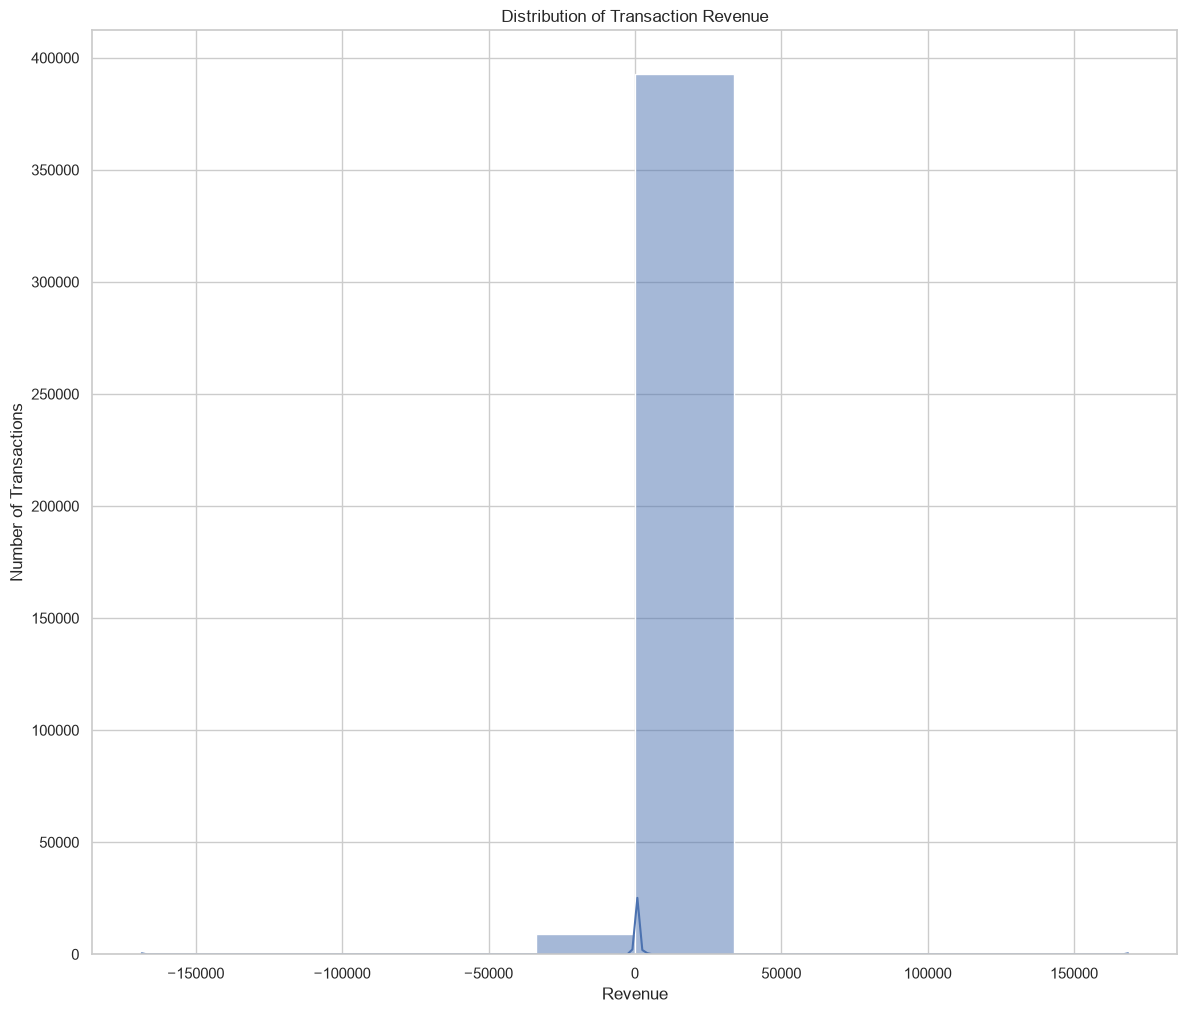

In [84]:
plt.figure(figsize=(14,12))
sns.histplot(
    data=df,
    x="Revenue",
    bins=10,
    kde=True
)

plt.title("Distribution of Transaction Revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of Transactions")

plt.show()

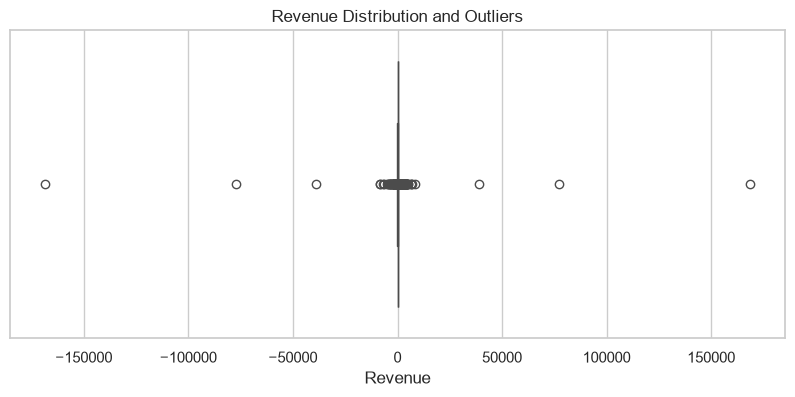

In [85]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x="Revenue"
)

plt.title("Revenue Distribution and Outliers")
plt.xlabel("Revenue")

plt.show()

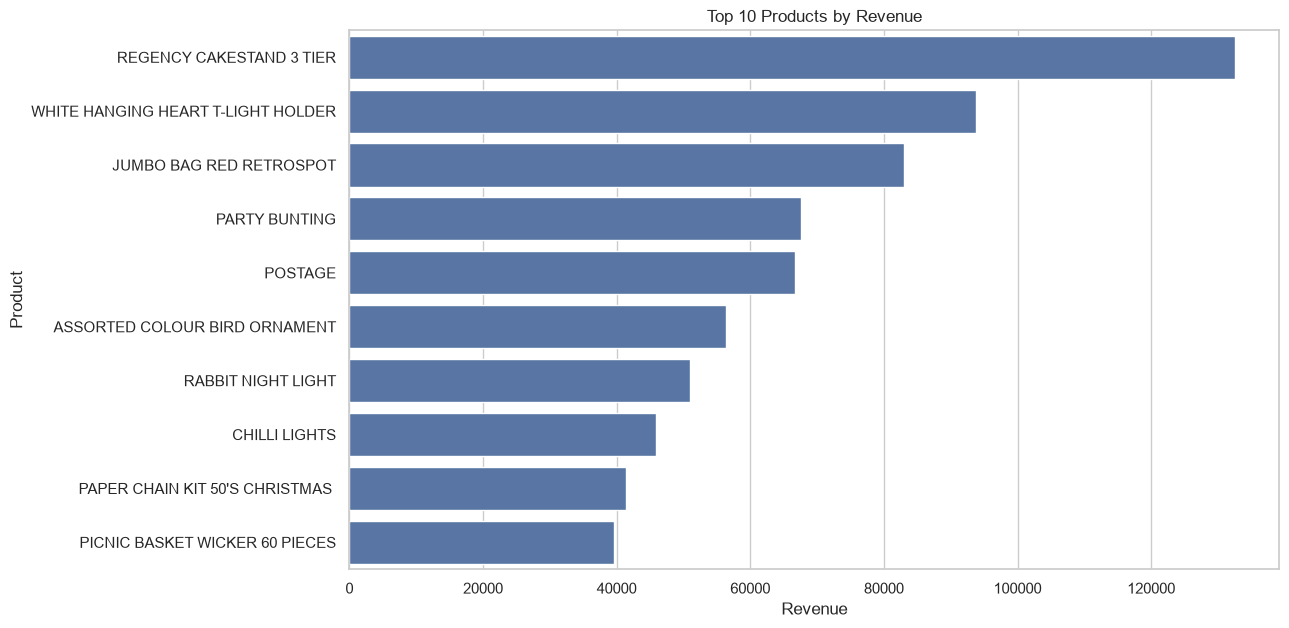

In [86]:
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_products,
    x="Revenue",
    y="Description"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

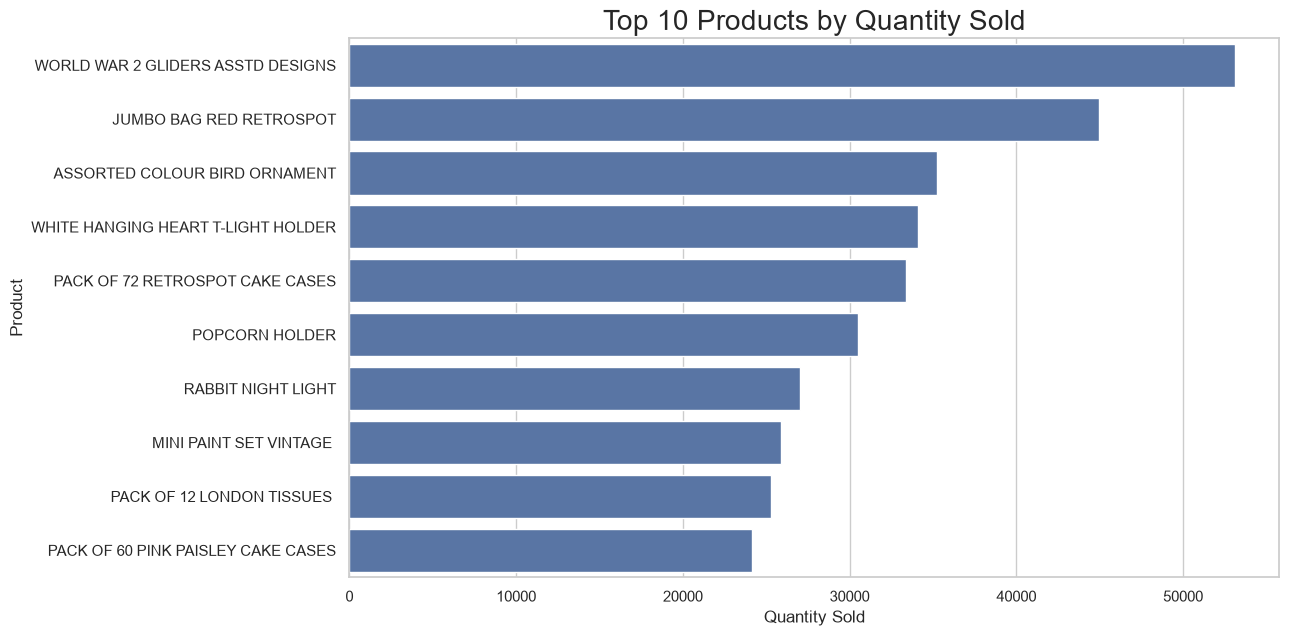

In [87]:
top_quantity_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_quantity_products,
    x="Quantity",
    y="Description"
)

plt.title("Top 10 Products by Quantity Sold",fontsize=20)
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.show()

In [88]:
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_countries = country_revenue.head(10)

top_countries



,Country,Revenue
0,United Kingdom,6745578.214
1,Netherlands,284661.540
2,EIRE,250001.780
3,Germany,221491.470
4,France,196626.050
5,Australia,137009.770
6,Switzerland,55739.400
7,Spain,54756.030
8,Belgium,40910.960
9,Sweden,36585.410


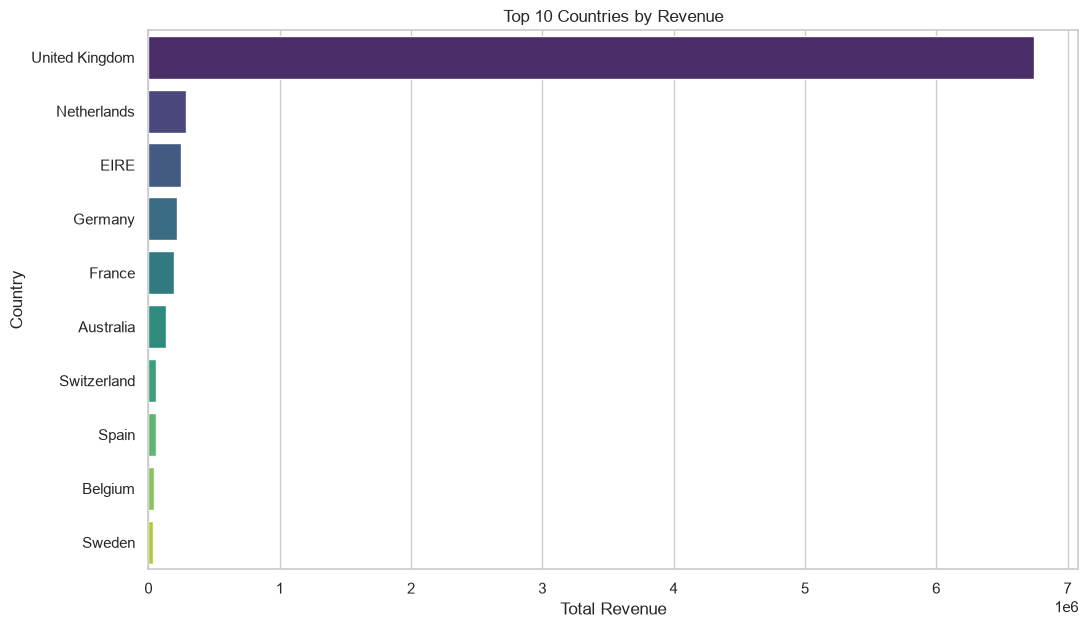

In [89]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_countries,
    x="Revenue",
    y="Country",
    hue="Country",
    legend=False,
    palette="viridis"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")

plt.show()

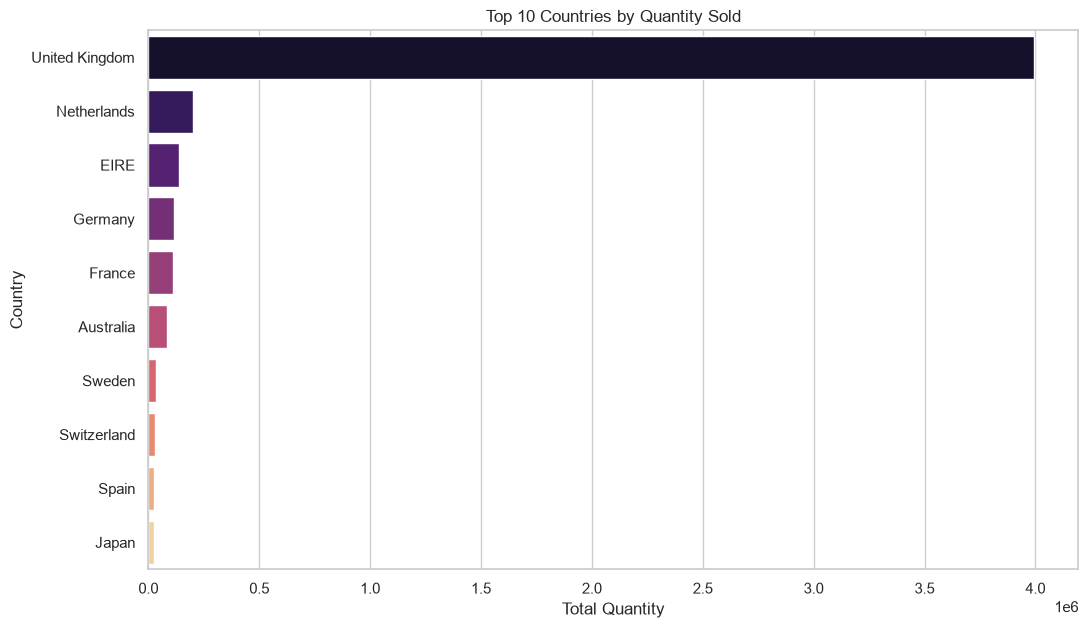

In [90]:
country_quantity = (
    df.groupby("Country")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_quantity_countries = country_quantity.head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_quantity_countries,
    x="Quantity",
    y="Country",
    hue="Country",
    legend=False,
    palette="magma"
)

plt.title("Top 10 Countries by Quantity Sold")
plt.xlabel("Total Quantity")
plt.ylabel("Country")

plt.show()

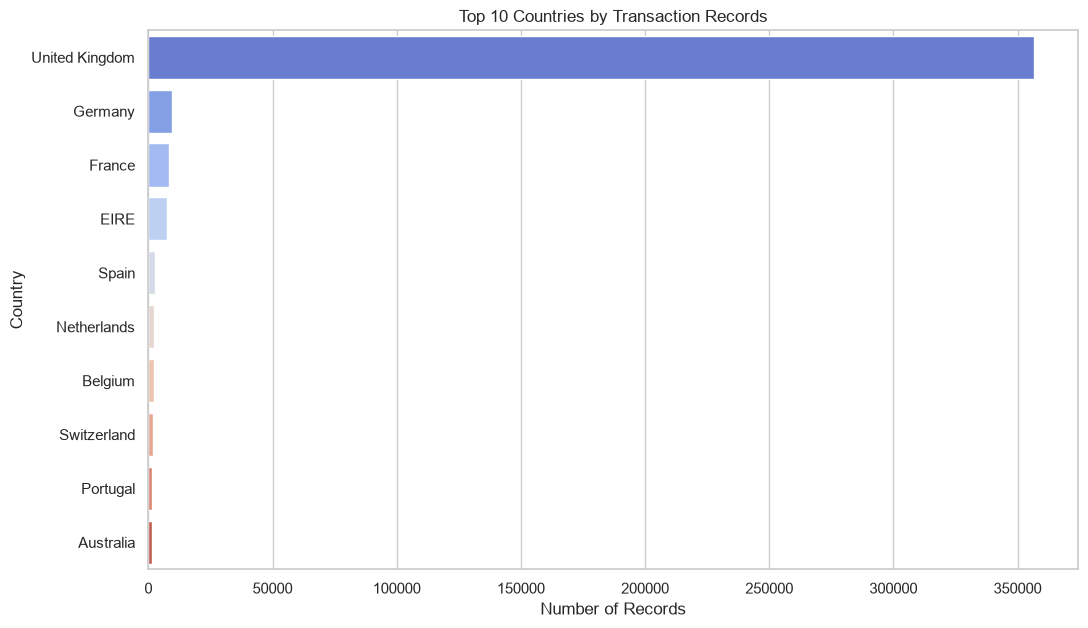

In [91]:
country_records = (
    df["Country"]
    .value_counts()
    .head(10)
    .reset_index()
)

country_records.columns = ["Country", "Records"]
plt.figure(figsize=(12, 7))

sns.barplot(
    data=country_records,
    x="Records",
    y="Country",
    hue="Country",
    legend=False,
    palette="coolwarm"
)

plt.title("Top 10 Countries by Transaction Records")
plt.xlabel("Number of Records")
plt.ylabel("Country")

plt.show()

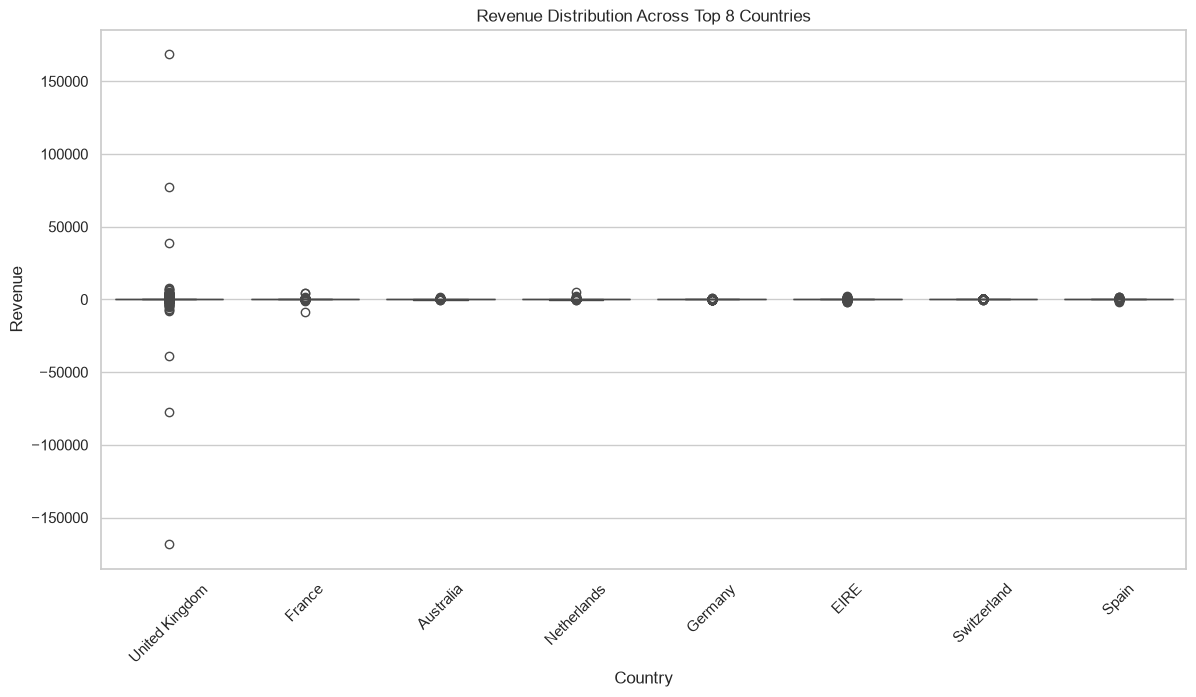

In [92]:
top_8_countries = (
    df.groupby("Country")["Revenue"]
    .sum()
    .nlargest(8)
    .index
)

country_data = df[df["Country"].isin(top_8_countries)]

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=country_data,
    x="Country",
    y="Revenue",
    hue="Country",
    legend=False
)

plt.title("Revenue Distribution Across Top 8 Countries")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

## Country Analysis — Observations

- The countries generating the highest total revenue are ...
- The country with the highest quantity sold is ...
- The country with the highest number of transaction records is ...
- The countries with the highest average transaction revenue are ...
- The boxplot shows that ...

In [93]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)

monthly_sales = (
    df.groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
)

print(monthly_sales)

   YearMonth      Revenue
0    2010-12   552315.160
1    2011-01   473659.300
2    2011-02   435531.570
3    2011-03   578533.910
4    2011-04   425217.671
5    2011-05   646905.470
6    2011-06   606861.270
7    2011-07   572192.571
8    2011-08   615068.090
9    2011-09   929141.582
10   2011-10   973201.140
11   2011-11  1126757.820
12   2011-12   341519.530


In [94]:
df["Revenue"]=df["Quantity"]*df['UnitPrice']
print(df)

                                Description  Quantity         InvoiceDate  \
0        WHITE HANGING HEART T-LIGHT HOLDER         6 2010-12-01 08:26:00   
1                       WHITE METAL LANTERN         6 2010-12-01 08:26:00   
2            CREAM CUPID HEARTS COAT HANGER         8 2010-12-01 08:26:00   
3       KNITTED UNION FLAG HOT WATER BOTTLE         6 2010-12-01 08:26:00   
4            RED WOOLLY HOTTIE WHITE HEART.         6 2010-12-01 08:26:00   
...                                     ...       ...                 ...   
541904          PACK OF 20 SPACEBOY NAPKINS        12 2011-12-09 12:50:00   
541905         CHILDREN'S APRON DOLLY GIRL          6 2011-12-09 12:50:00   
541906        CHILDRENS CUTLERY DOLLY GIRL          4 2011-12-09 12:50:00   
541907      CHILDRENS CUTLERY CIRCUS PARADE         4 2011-12-09 12:50:00   
541908        BAKING SET 9 PIECE RETROSPOT          3 2011-12-09 12:50:00   

        UnitPrice  CustomerID         Country  Revenue  Year  Month MonthNa

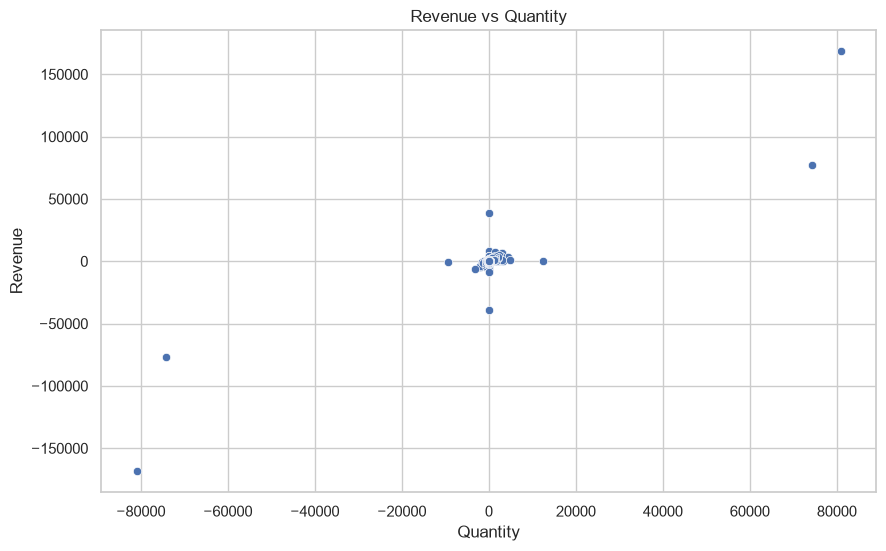

In [95]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Quantity",
    y="Revenue",
)
plt.title("Revenue vs Quantity")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()


In [96]:
hourly_sales = (
    df.groupby("Hour")["Revenue"]
    .sum()
    .reset_index()
)

print(hourly_sales)

    Hour      Revenue
0      6     -497.350
1      7    31009.320
2      8   279975.430
3      9   654884.151
4     10  1147608.331
5     11  1053631.680
6     12  1332220.930
7     13  1117875.640
8     14   944998.271
9     15   896284.490
10    16   445886.100
11    17   212357.001
12    18   100525.120
13    19    44225.880
14    20    15920.090


In [98]:
best_hour = hourly_sales.loc[
    hourly_sales["Revenue"].idxmax()
]

print("Highest Revenue Hour:")
print(best_hour)

lowest_hour = hourly_sales.loc[
    hourly_sales["Revenue"].idxmin()
]

print("Lowest Revenue Hour:")
print(lowest_hour)

Highest Revenue Hour:
Hour            12.00
Revenue    1332220.93
Name: 6, dtype: float64
Lowest Revenue Hour:
Hour         6.00
Revenue   -497.35
Name: 0, dtype: float64


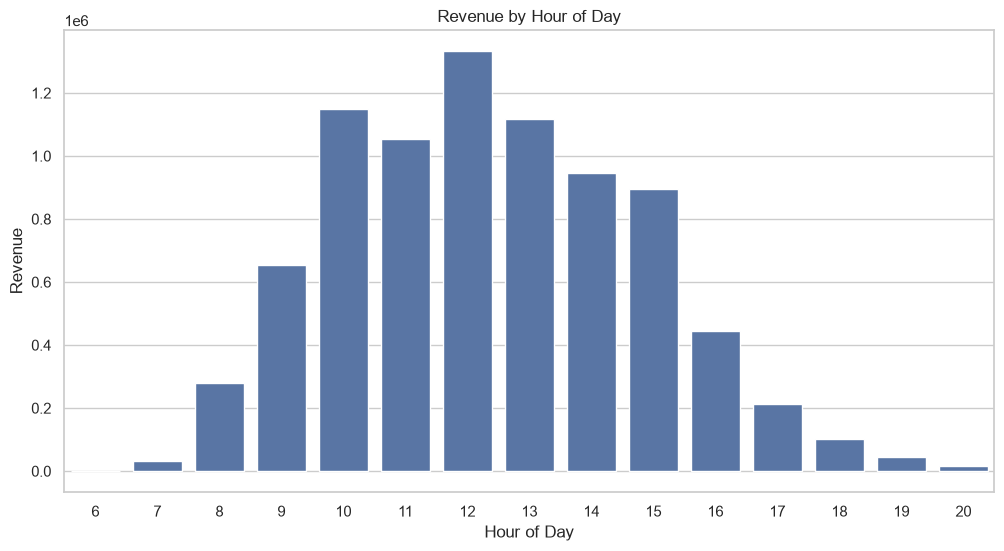

In [99]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=hourly_sales,
    x="Hour",
    y="Revenue"
)

plt.title("Revenue by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")

plt.show()

In [102]:
customer_data = (
    df.groupby("CustomerID")
    .agg(
        TotalRevenue=("Revenue", "sum"),
        TotalQuantity=("Quantity", "sum"),
        Transactions=("InvoiceDate", "count"),
        AverageOrderValue=("Revenue", "mean"),
        UniqueProducts=("Description", "nunique"),
        Country=("Country", "first")
    )
    .reset_index()
)

customer_data.head()

top_customers = (
    customer_data
    .sort_values("TotalRevenue", ascending=False)
    .head(10)
)

top_customers

def customer_segment(revenue):
    if revenue >= 5000:
        return "High Value"
    elif revenue >= 1000:
        return "Medium Value"
    else:
        return "Low Value"

customer_data["Segment"] = customer_data["TotalRevenue"].apply(
    customer_segment
)

segment_summary = (
    customer_data
    .groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Revenue=("TotalRevenue", "sum"),
        AverageRevenue=("TotalRevenue", "mean")
    )
    .reset_index()
)

segment_summary

,Segment,Customers,Revenue,AverageRevenue
0,High Value,262,4255852.550,16243.712023
1,Low Value,2742,1092264.933,398.346073
2,Medium Value,1368,2928787.601,2140.926609


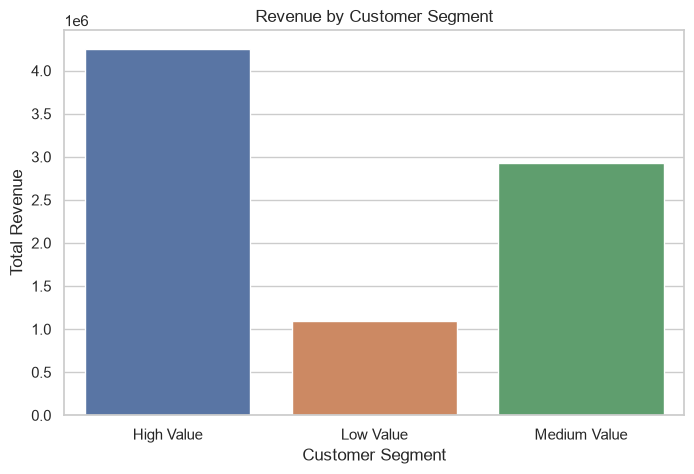

In [103]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=segment_summary,
    x="Segment",
    y="Revenue",
    hue="Segment",
    legend=False
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.show()

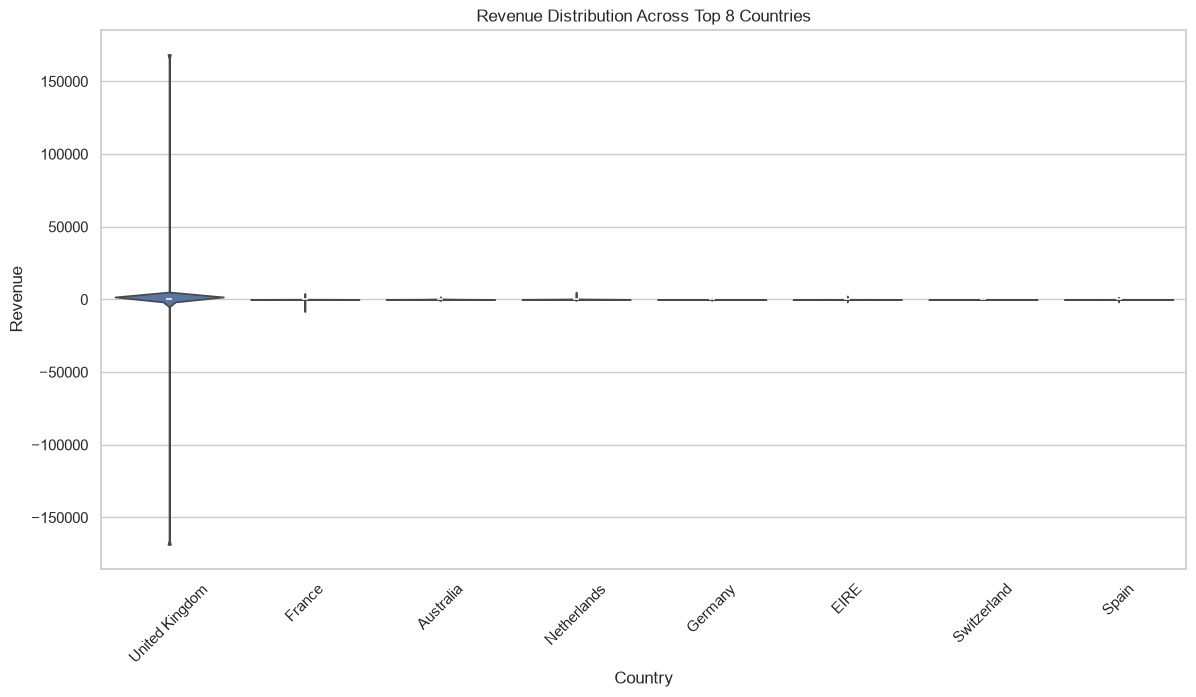

In [104]:
plt.figure(figsize=(14, 7))

sns.violinplot(
    data=country_data,
    x="Country",
    y="Revenue",
    hue="Country",
    legend=False
)

plt.title("Revenue Distribution Across Top 8 Countries")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

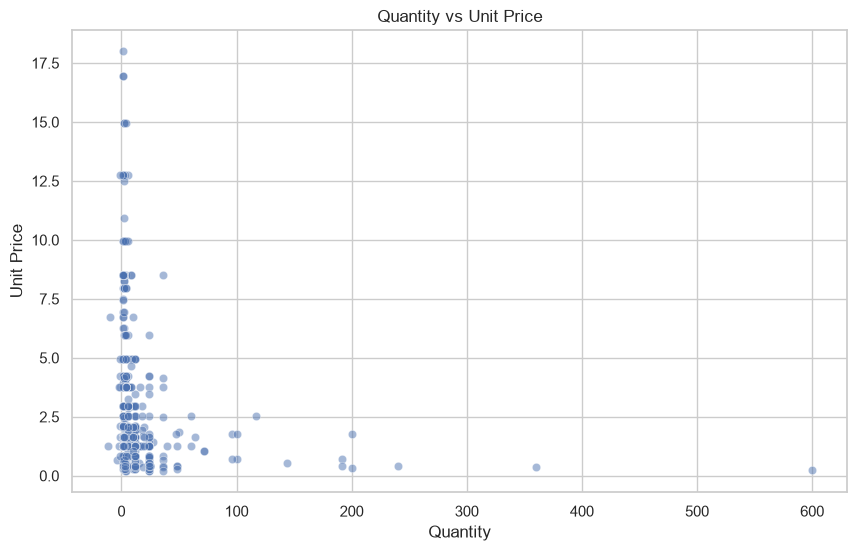

In [106]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(500),
    x="Quantity",
    y="UnitPrice",
    alpha=0.5
)

plt.title("Quantity vs Unit Price")
plt.xlabel("Quantity")
plt.ylabel("Unit Price")

plt.show()

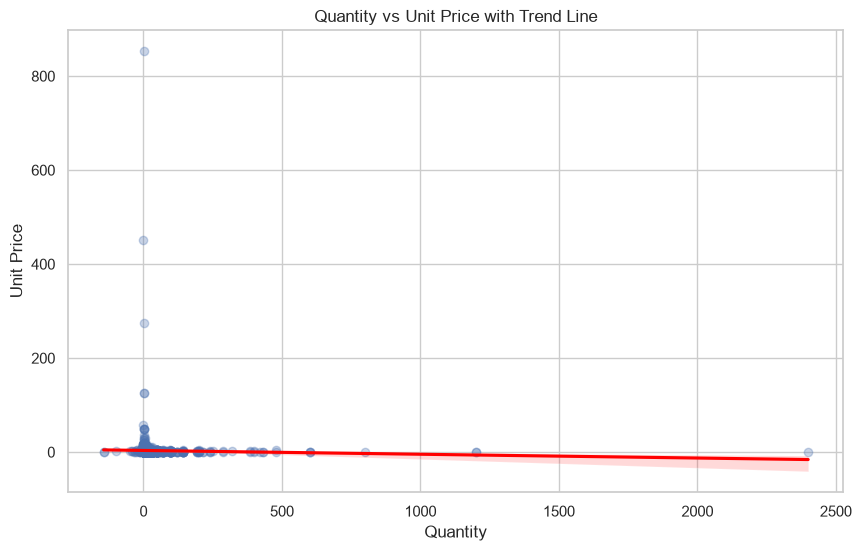

In [107]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df.sample(5000),
    x="Quantity",
    y="UnitPrice",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Quantity vs Unit Price with Trend Line")
plt.xlabel("Quantity")
plt.ylabel("Unit Price")

plt.show()

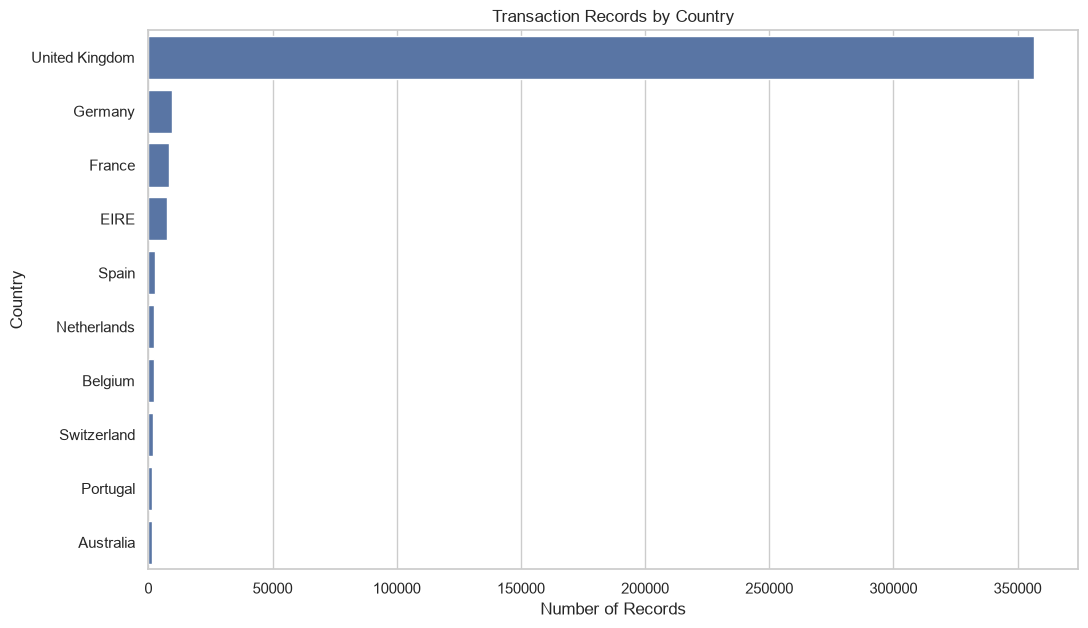

In [108]:
top_country_names = df["Country"].value_counts().head(10).index

country_sample = df[
    df["Country"].isin(top_country_names)
]

plt.figure(figsize=(12, 7))

sns.countplot(
    data=country_sample,
    y="Country",
    order=top_country_names
)

plt.title("Transaction Records by Country")
plt.xlabel("Number of Records")
plt.ylabel("Country")

plt.show()

In [109]:
sales_df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()

top_5_countries = sales_df["Country"].value_counts().head(5).index

strip_data = sales_df[
    sales_df["Country"].isin(top_5_countries)
].sample(1000)


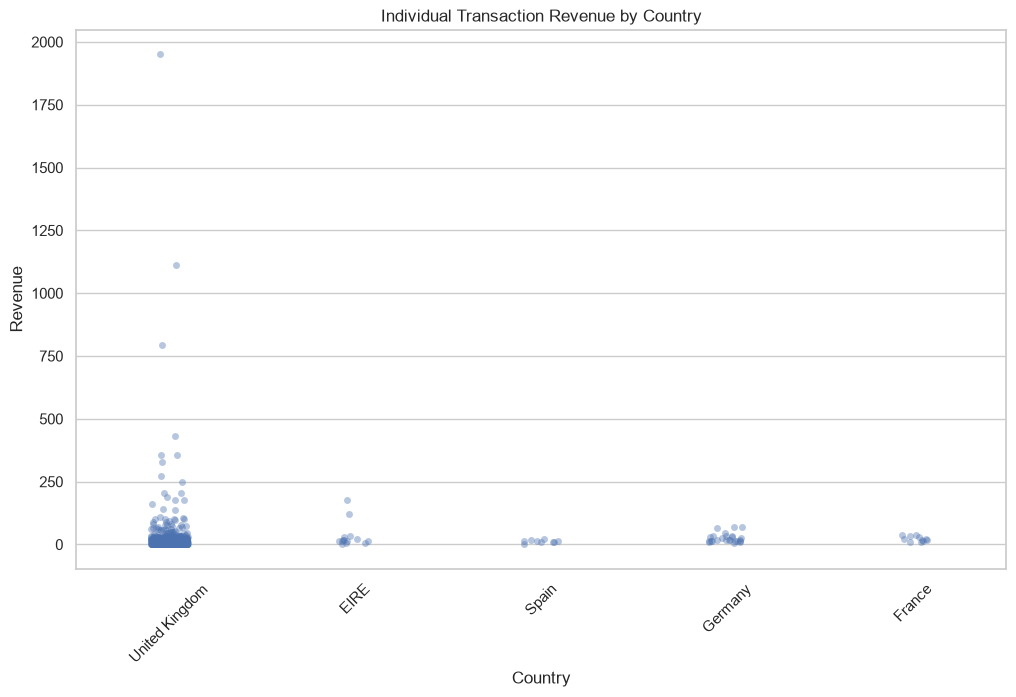

In [110]:
plt.figure(figsize=(12, 7))

sns.stripplot(
    data=strip_data,
    x="Country",
    y="Revenue",
    jitter=True,
    alpha=0.4
)

plt.title("Individual Transaction Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()


c:\Users\Savan\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 59.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\Savan\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 58.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


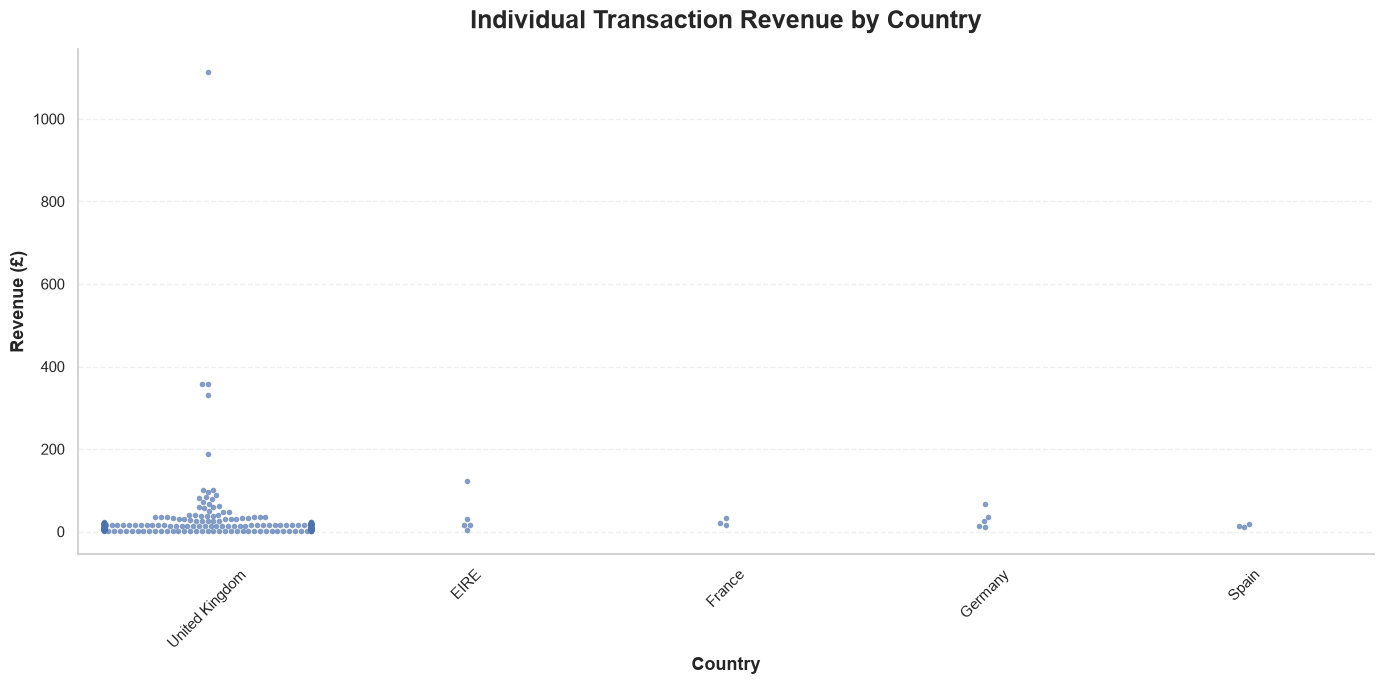

In [111]:
plt.figure(figsize=(14, 7))

sns.swarmplot(
    data=strip_data.sample(300),
    x="Country",
    y="Revenue",
    size=4,
    alpha=0.7
)

plt.title(
    "Individual Transaction Revenue by Country",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Country",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Revenue (£)",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(
    rotation=45,
    fontsize=11
)

plt.yticks(fontsize=11)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

sns.despine()

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

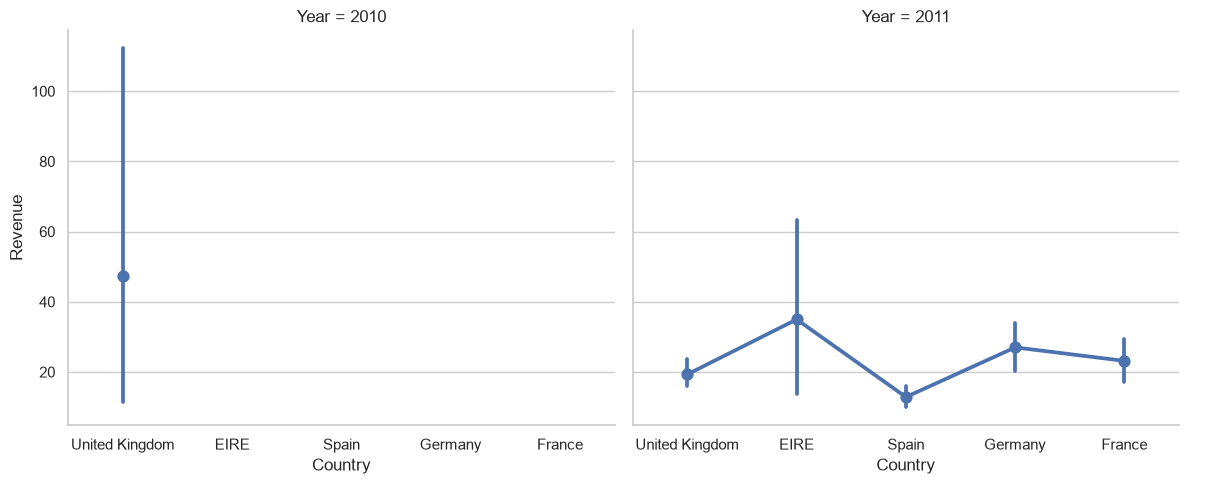

In [112]:
plt.figure(figsize=(12, 6))

sns.catplot(
    data=strip_data,
    x="Country",
    y="Revenue",
    col="Year",
    kind="point",
    height=5,
    aspect=1.2
)

plt.show()

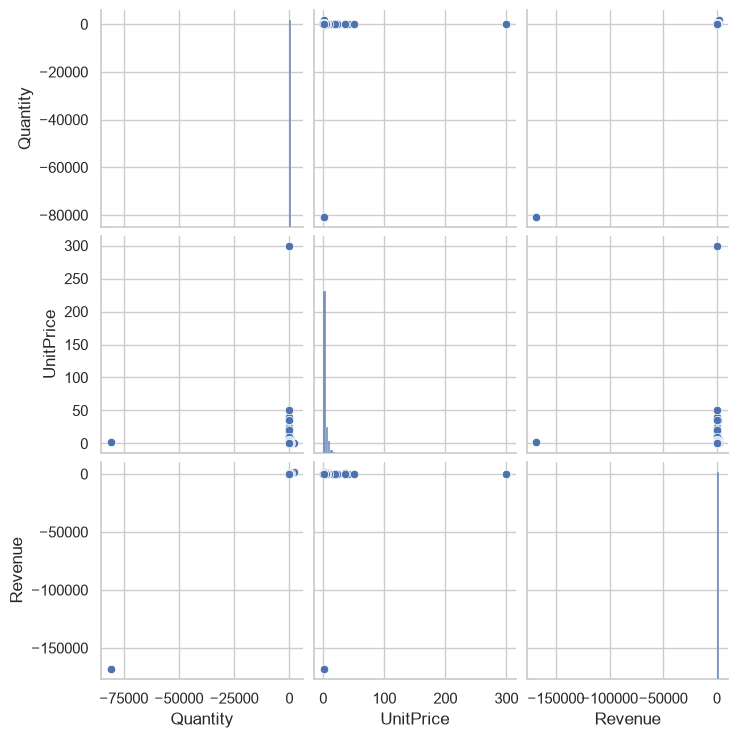

In [113]:
pair_data = df[
    ["Quantity", "UnitPrice", "Revenue"]
].sample(1500)

sns.pairplot(
    pair_data,
    diag_kind="hist"
)

plt.show()

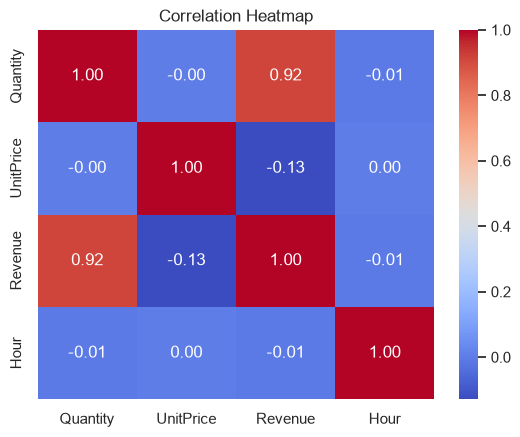

In [114]:
corr = df[["Quantity", "UnitPrice", "Revenue", "Hour"]].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

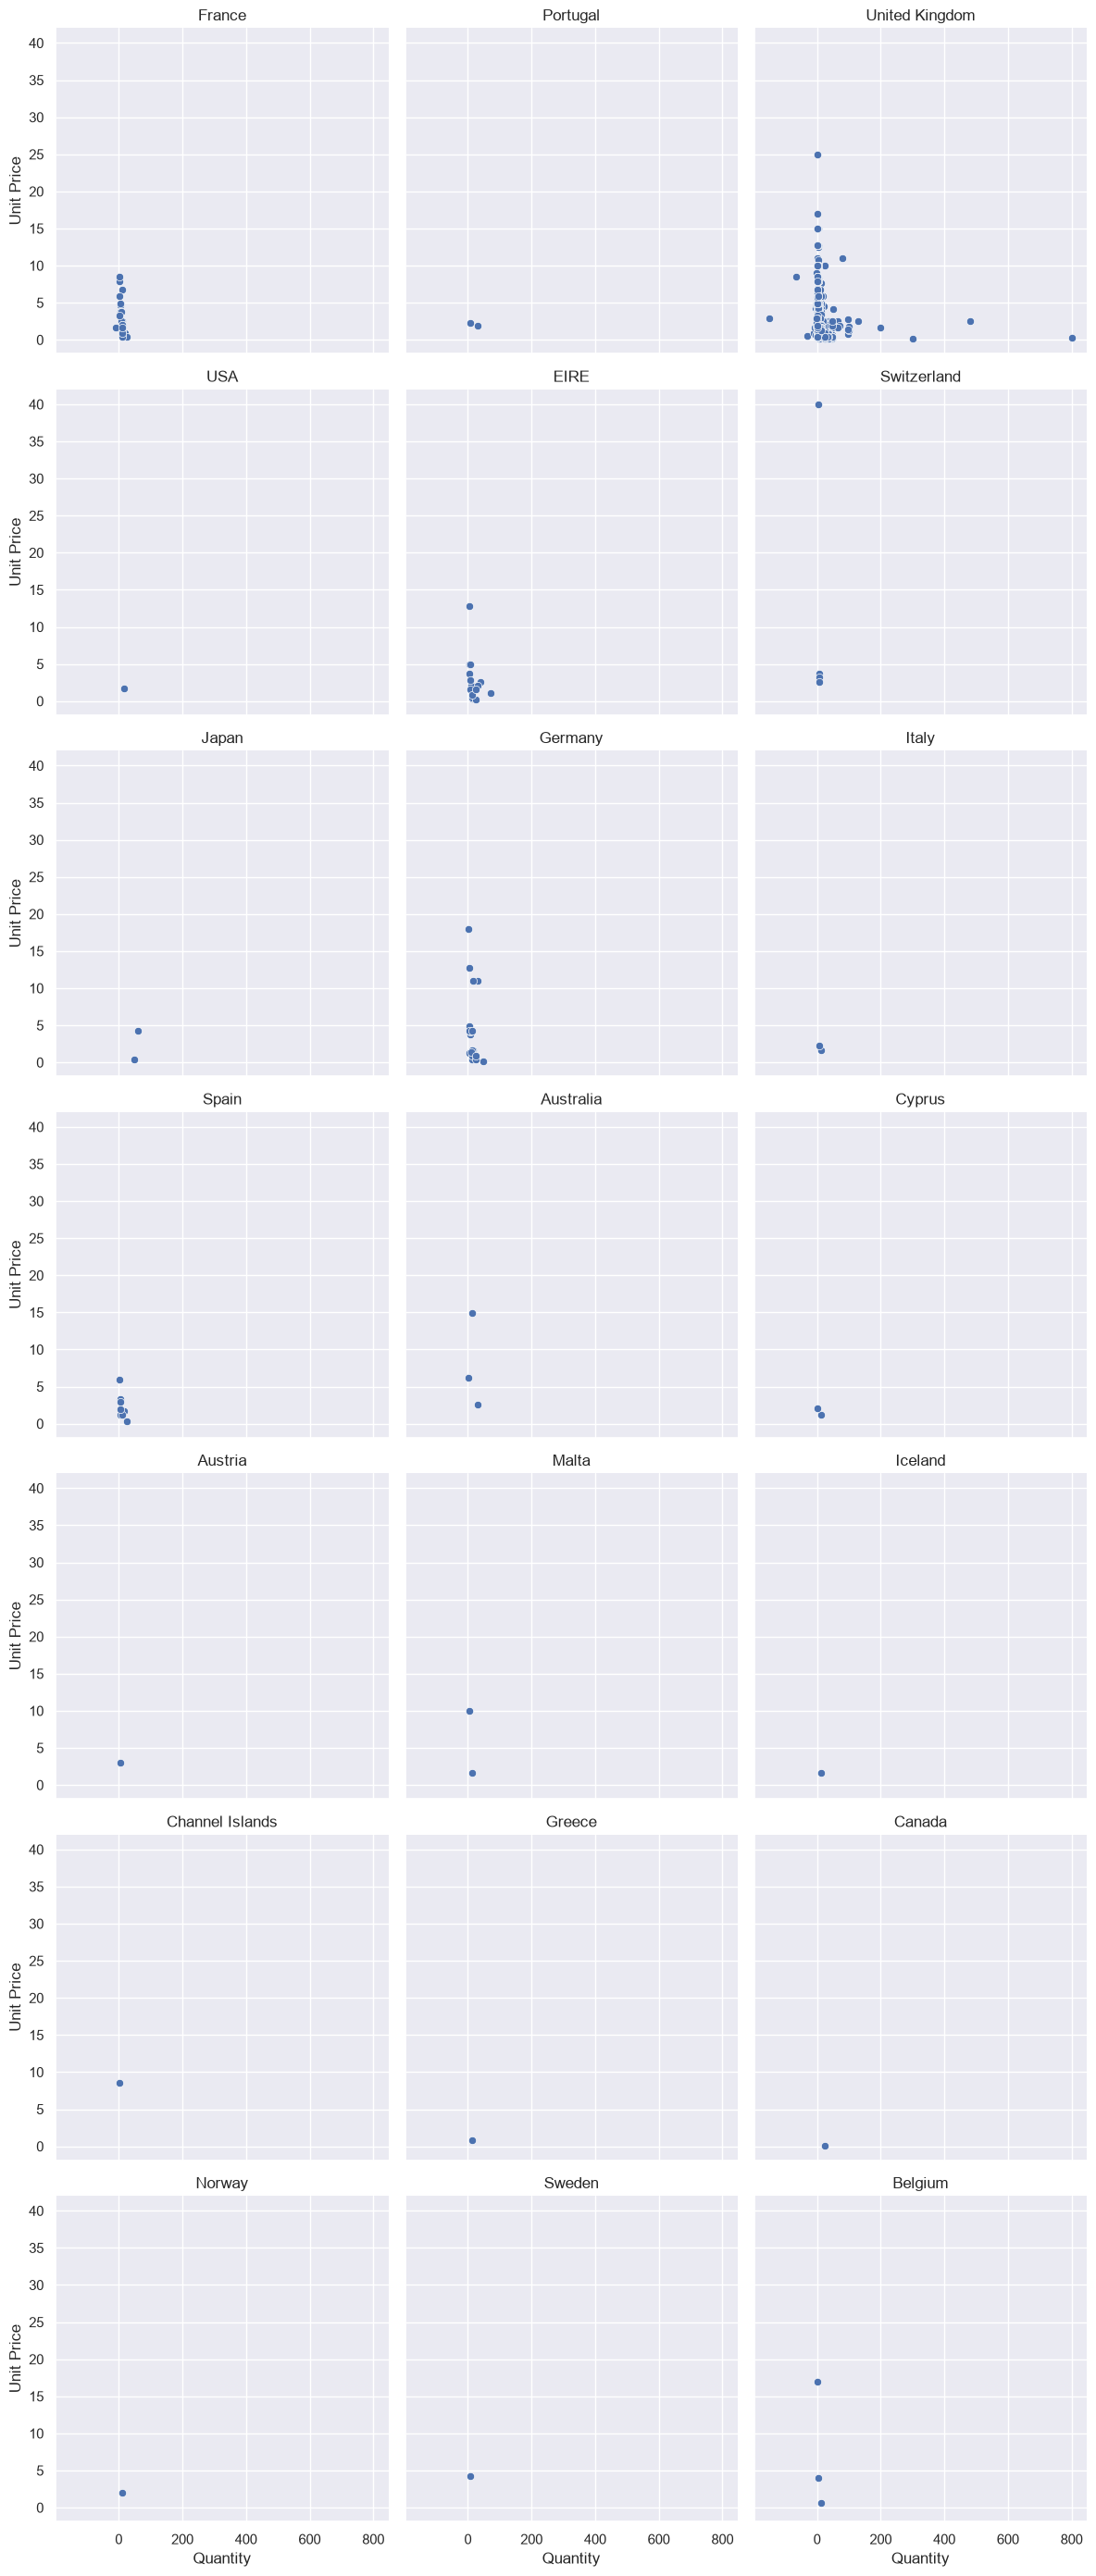

In [118]:
facet_data = df.sample(1000)
sns.set_theme(style="darkgrid")
g = sns.FacetGrid(
    facet_data,
    col="Country",
    col_wrap=3,
    height=4
)

g.map_dataframe(
    sns.scatterplot,
    x="Quantity",
    y="UnitPrice"
)

g.set_axis_labels("Quantity", "Unit Price")
g.set_titles("{col_name}")

plt.show()

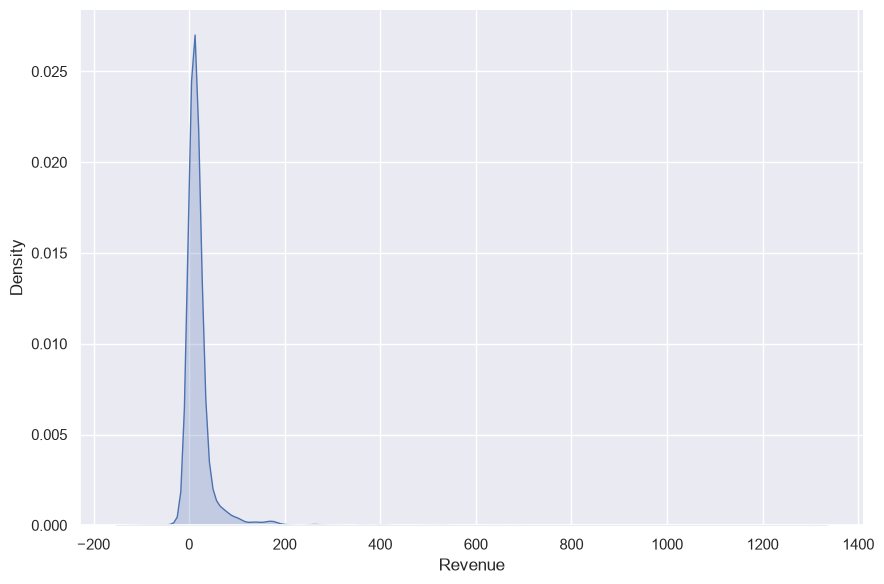

In [117]:
sns.set_theme(style="darkgrid")
sns.displot(
    data=df.sample(3000),
    x="Revenue",
    kind="kde",
    fill=True,
    height=6,
    aspect=1.5
)

plt.show()